## Analyzing the Translation Memory

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

translation_memory_path = "data/tm/translation_memory.jsonl"  # Path to the combined JSONL file
# Load the combined JSONL file into a DataFrame
translation_memory_df = pd.read_json(translation_memory_path, lines=True)



In [18]:
translation_memory_df.head()

,id,source_file,source,target,msgctxt,wml+context,occurrences,flags,msgid_plural,msgstr
0,ba0226ef0d4ca5f687826d656ec8e944,pl_help.po,Underground,Podziemie,NaN,[time]: id=underground\n[editor_times]: id=und...,[[data/campaigns/Heir_To_The_Throne_Classic/ut...,[],,Podziemie
1,edcb46a154444bd7aa2e41c45ff006f1,pl_help.po,undead,nieumarły,NaN,[label]\n[trait]: id=undead,[[data/campaigns/Secrets_of_the_Ancients/gui/z...,[],,nieumarły
2,ccb8b15a2862c98456173cbcd6d45278,pl_help.po,fearless,nieustraszony,NaN,[label]\n[chance]\n[trait]: id=fearless,[[data/campaigns/Secrets_of_the_Ancients/gui/z...,[],,nieustraszony
3,b37819dfe6c948960e1b25d24f2036a4,pl_help.po,plague,zaraza,NaN,"[label]\n[plague]: id=SotA_plague, type=null #...",[[data/campaigns/Secrets_of_the_Ancients/gui/z...,[],,zaraza
4,17eaafd8ab51879f3917ade13077fee3,pl_help.po,"When a unit is killed by a Plague attack, that...",Zaraza:\nJednostka zabita atakiem z zarazą zos...,NaN,"[plague]: id=SotA_plague, type=null # prevents...",[[data/campaigns/Secrets_of_the_Ancients/utils...,[],,Zaraza:\nJednostka zabita atakiem z zarazą zos...


In [20]:
translation_memory_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1624 entries, 0 to 1623
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1624 non-null   str    
 1   source_file   1624 non-null   str    
 2   source        1624 non-null   str    
 3   target        1624 non-null   str    
 4   msgctxt       0 non-null      float64
 5   wml+context   1624 non-null   str    
 6   occurrences   1624 non-null   object 
 7   flags         1624 non-null   object 
 8   msgid_plural  1624 non-null   str    
 9   msgstr        1624 non-null   str    
dtypes: float64(1), object(2), str(7)
memory usage: 127.0+ KB


In [25]:
# Count total source entries
total_source_entries = len(translation_memory_df)
print(f"Total source entries: {total_source_entries}")

Total source entries: 1624


In [ ]:
# Count total characters in source strings
total_source_characters = sum(len(entry) for entry in translation_memory_df["source"])
print(f"Total characters in source strings: {total_source_characters}")

Total characters in source strings: 195374


In [39]:
# Count total words in source strings
total_source_words = sum(len(entry.split()) for entry in translation_memory_df["source"])
print(f"Total words in source strings: {total_source_words}")

Total words in source strings: 33119


In [ ]:
# Counting total characters in target strings
total_target_characters = sum(len(entry) for entry in translation_memory_df["target"])
print(f"Total characters in target strings: {total_target_characters}")

Total characters in target strings: 209544


In [40]:
# Count total words in target strings
total_target_words = sum(len(entry.split()) for entry in translation_memory_df["target"])
print(f"Total words in target strings: {total_target_words}")

Total words in target strings: 29427


In [49]:
# Distribution of source string lengths in words
translation_memory_df["source_length_words"] = translation_memory_df["source"].apply(lambda x: len(x.split()))
bins = [0, 5, 15, 30, 60, 100, np.inf]
labels = ["0-4", "5-14", "15-29", "30-59", "60-99", "100+"]

translation_memory_df["source_length_category"] = pd.cut(translation_memory_df["source_length_words"], 
                                                         bins=bins, 
                                                         labels=labels, 
                                                         right=False)
source_length_distribution = translation_memory_df["source_length_category"].value_counts().sort_index()
print("Distribution of source string lengths in words:")
print(source_length_distribution)

Distribution of source string lengths in words:
source_length_category
0-4      926
5-14     159
15-29    135
30-59    212
60-99    132
100+      60
Name: count, dtype: int64


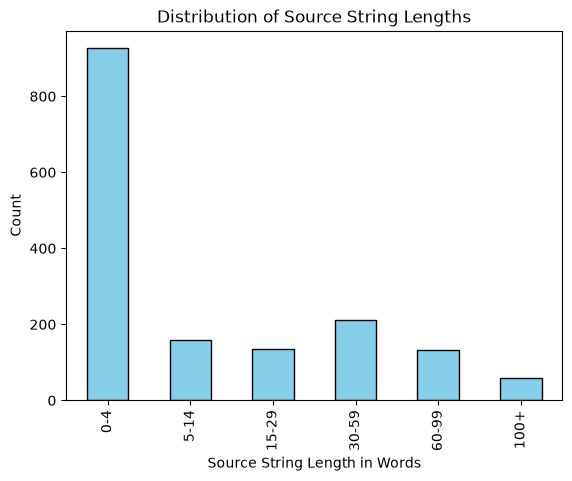

In [50]:
histogram_source = source_length_distribution.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of Source String Lengths")
plt.xlabel("Source String Length in Words")
plt.ylabel("Count")
plt.show()

In [51]:
# Distribution of target string lengths in words
translation_memory_df["target_length_words"] = translation_memory_df["target"].apply(lambda x: len(x.split()))
bins = [0, 5, 15, 30, 60, 100, np.inf]
labels = ["0-4", "5-14", "15-29", "30-59", "60-99", "100+"]

translation_memory_df["target_length_category"] = pd.cut(translation_memory_df["target_length_words"], 
                                                         bins=bins, 
                                                         labels=labels, 
                                                         right=False)
target_length_distribution = translation_memory_df["target_length_category"].value_counts().sort_index()
print("Distribution of target string lengths in words:")
print(target_length_distribution)

Distribution of target string lengths in words:
target_length_category
0-4      942
5-14     171
15-29    137
30-59    222
60-99    111
100+      41
Name: count, dtype: int64


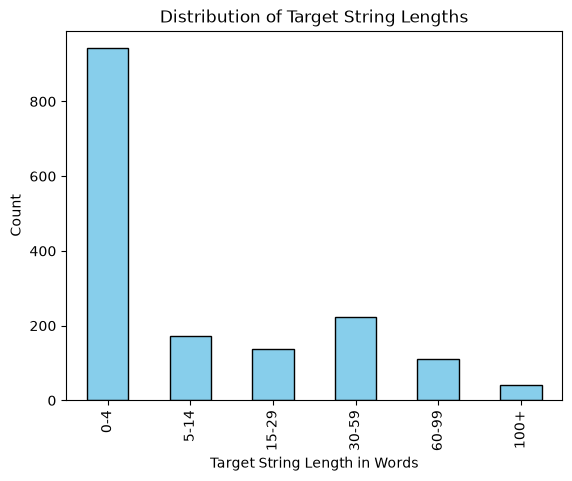

In [52]:
histogram_target = target_length_distribution.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of Target String Lengths")
plt.xlabel("Target String Length in Words")
plt.ylabel("Count")
plt.show()

In [23]:
# Counting records with variables
records_with_variables = translation_memory_df[translation_memory_df["source"].str.contains(r"\$\w+")]
print(f"Records with variables: {len(records_with_variables)}")

Records with variables: 11
